In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing

In [6]:
data = fetch_california_housing()
X_cal, y_cal = data.data , data.target 

In [7]:
Xc_train , Xc_test , yc_train , yc_test = train_test_split(X_cal , y_cal , test_size = 0.2 , random_state = 42)
model_cal = LinearRegression().fit(Xc_train , yc_train)
y_pred_cal = model_cal.predict(Xc_test)
mse_cal = mean_squared_error(yc_test , y_pred_cal)
print(f"MSE ( california Housing) : {mse_cal :.2f}")

MSE ( california Housing) : 0.56


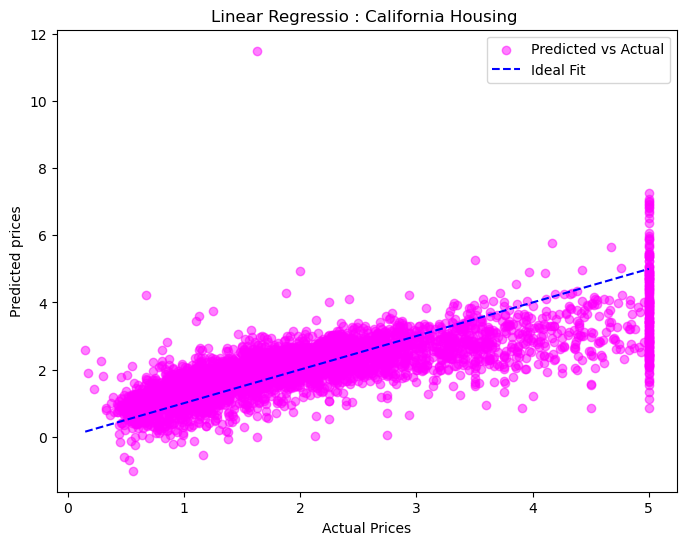

In [9]:
plt.figure(figsize = (8,6))
plt.scatter(yc_test , y_pred_cal , color = "magenta" , alpha = 0.5 , label = "Predicted vs Actual")
plt.plot([yc_test.min() , yc_test.max()],
         [yc_test.min() , yc_test.max()],
         color = "blue",
         linestyle = "--" , label = "Ideal Fit")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted prices")
plt.title("Linear Regressio : California Housing ")
plt.legend()
plt.show()

In [13]:
df = pd.read_csv(r'C:\Users\Devops Lab-B2\Desktop\4CB23CB045\7th_dataset_auto-mpg.csv')

In [14]:
X_auto = df[[ 'displacement' , 'weight', 'acceleration']]
y_auto = df['mpg']
Xa_train , Xa_test , ya_train , ya_test = train_test_split(X_auto , y_auto , test_size = 0.2 , random_state = 42)

In [19]:
scalar = StandardScaler()
Xa_train_s = scalar.fit_transform(Xa_train)
Xa_test_s = scalar.transform(Xa_test)
poly = PolynomialFeatures(degree = 2)
Xa_train_p = poly.fit_transform(Xa_train_s)
Xa_test_p = poly.transform(Xa_test_s)

In [21]:
model_auto = LinearRegression().fit(Xa_train_p , ya_train)
y_pred_auto = model_auto.predict(Xa_test_p)
mse_auto = mean_squared_error(ya_test, y_pred_auto)
print(f"MSE(Auto-MPG polynomial) : {mse_auto:.2f}")

MSE(Auto-MPG polynomial) : 11.99


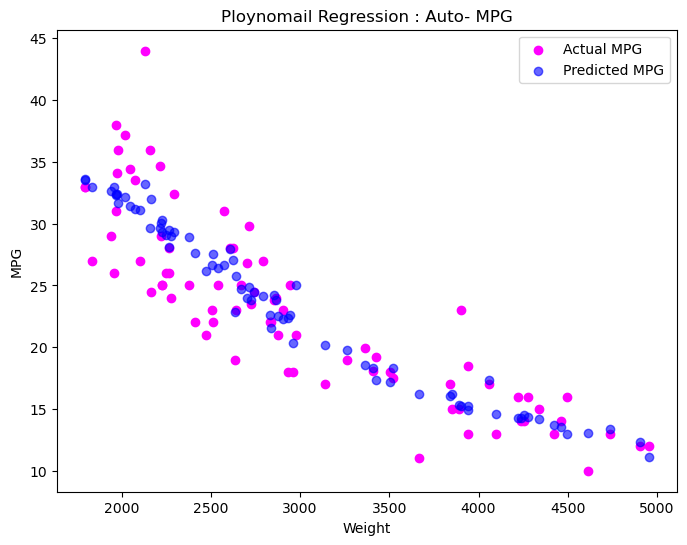

In [24]:
plt.figure(figsize = (8,6))
plt.scatter(Xa_test['weight'] , ya_test , color = "magenta" , label = "Actual MPG")
plt.scatter(Xa_test['weight'] , y_pred_auto , color = "blue" , alpha = 0.6 , label = "Predicted MPG" )
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Ploynomail Regression : Auto- MPG")
plt.legend()
plt.show()